In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Set Seaborn style for all plots (makes them look professional)
sns.set_theme(style='whitegrid', palette='muted')
# Load cleaned data from Task 1
df = pd.read_csv('titanic_cleaned.csv')
print('Data loaded. Shape:', df.shape)

Data loaded. Shape: (891, 14)


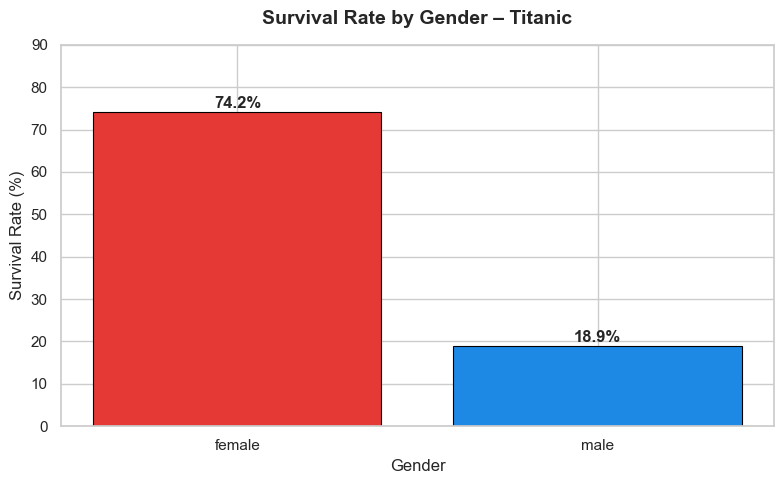

Chart 1 saved!


In [3]:
fig, ax = plt.subplots(figsize=(8, 5)) # Create a figure (8 inches wide, 5 tall)
# Count survivors by sex and plot
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
colors_list = ['#E53935', '#1E88E5'] # Red for female, Blue for male
bars = ax.bar(survival_by_sex.index, survival_by_sex.values,
color=colors_list, edgecolor='black', linewidth=0.8)
# Add value labels ON TOP of each bar
for bar, val in zip(bars, survival_by_sex.values):
 ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Survival Rate by Gender – Titanic', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Survival Rate (%)', fontsize=12)
ax.set_ylim(0, 90)
plt.tight_layout()
plt.savefig('chart1_survival_by_gender.png', dpi=150)
plt.show()
print('Chart 1 saved!')

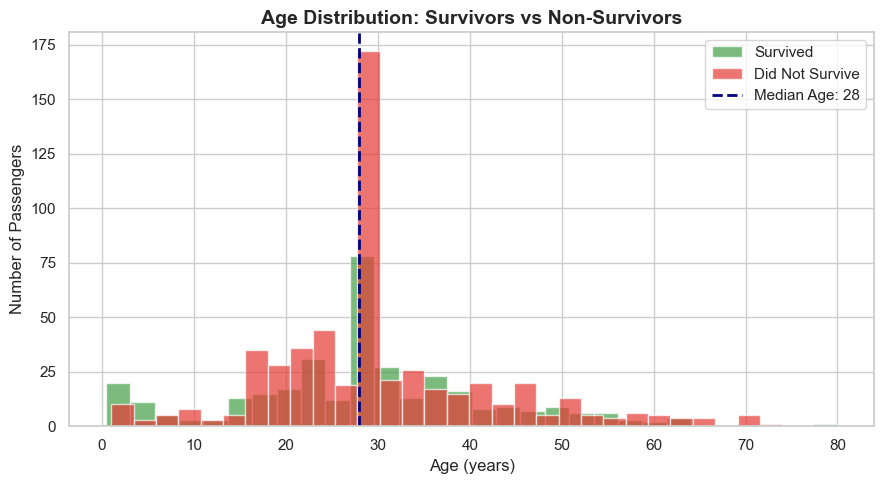

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
# Plot separate histograms for survivors vs non-survivors
df[df['Survived']==1]['Age'].hist(bins=30, alpha=0.7, label='Survived',

color='#43A047', ax=ax)

df[df['Survived']==0]['Age'].hist(bins=30, alpha=0.7, label='Did Not Survive',

color='#E53935', ax=ax)

ax.set_title('Age Distribution: Survivors vs Non-Survivors', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Number of Passengers', fontsize=12)
ax.legend(fontsize=11)
# Add a vertical line at median age
median_age = df['Age'].median()
ax.axvline(median_age, color='navy', linestyle='--', linewidth=2,

label=f'Median Age: {median_age:.0f}')

ax.legend()
plt.tight_layout()
plt.savefig('chart2_age_distribution.png', dpi=150)
plt.show()

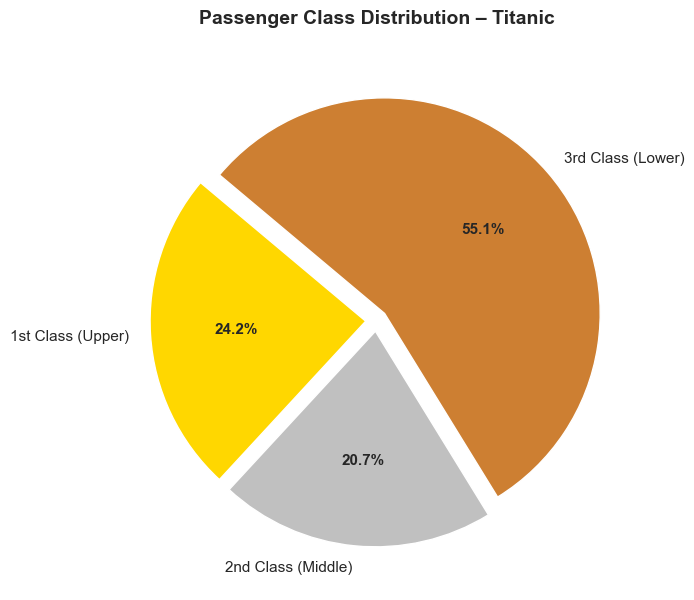

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
class_counts = df['Pclass'].value_counts().sort_index()
labels = ['1st Class (Upper)', '2nd Class (Middle)', '3rd Class (Lower)']
colors_pie = ['#FFD700', '#C0C0C0', '#CD7F32'] # Gold, Silver, Bronze
explode = (0.05, 0.05, 0.05) # Slightly separate all slices
wedges, texts, autotexts = ax.pie(
class_counts.values, labels=labels, colors=colors_pie,
autopct='%1.1f%%', explode=explode, startangle=140,
textprops={'fontsize': 11})
# Make percentage text bold
for autotext in autotexts:
 autotext.set_fontweight('bold')
ax.set_title('Passenger Class Distribution – Titanic', fontsize=14, fontweight='bold', pad=20)
plt.savefig('chart3_class_distribution.png', dpi=150)
plt.show()

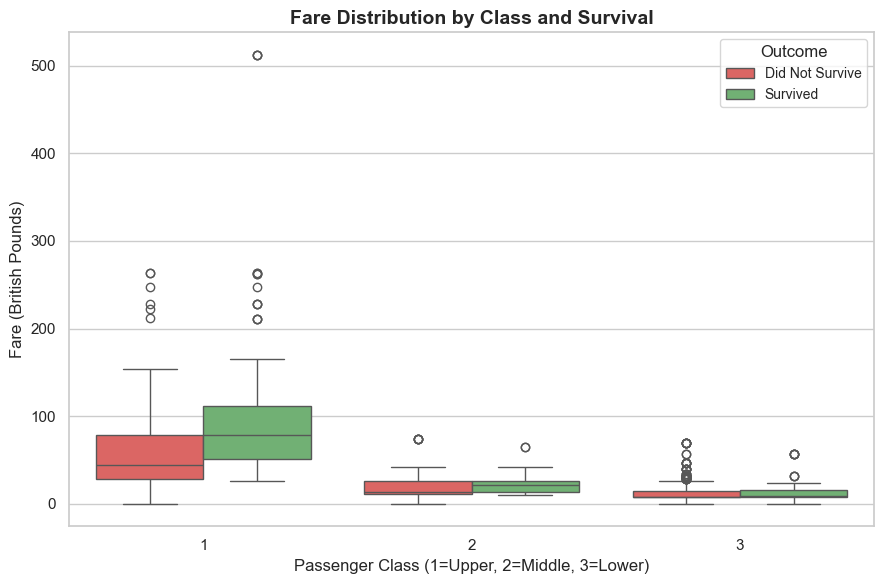

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
# Seaborn boxplot - notice how SHORT the code is compared to Matplotlib!
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Survived',
palette={0: '#EF5350', 1: '#66BB6A'}, ax=ax)

ax.set_title('Fare Distribution by Class and Survival', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class (1=Upper, 2=Middle, 3=Lower)', fontsize=12)
ax.set_ylabel('Fare (British Pounds)', fontsize=12)
# Rename legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Did Not Survive', 'Survived'], title='Outcome', fontsize=10)
plt.tight_layout()
plt.savefig('chart4_fare_boxplot.png', dpi=150)
plt.show()

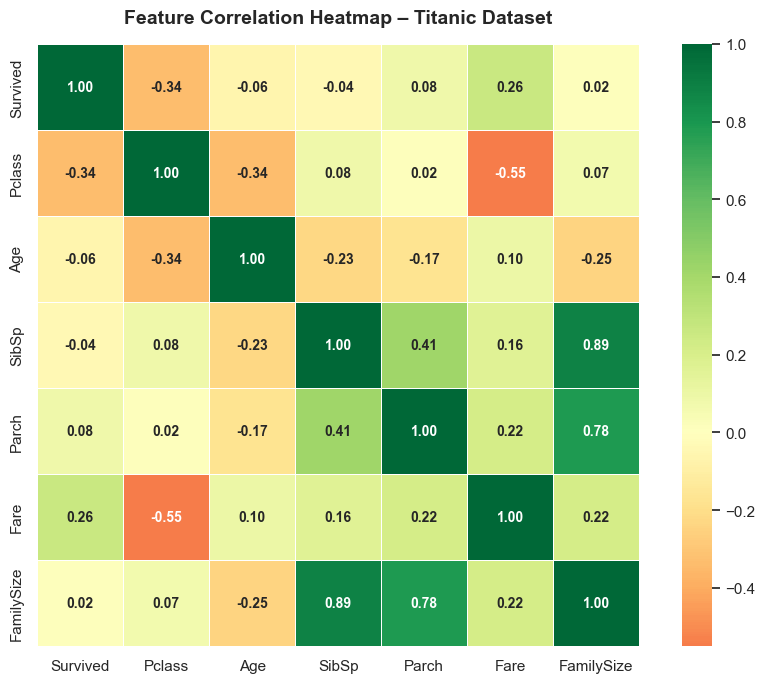

Highest correlation with Survival:
Survived      1.000000
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.064910
Pclass       -0.338481
Name: Survived, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
# Select only numeric columns
numeric_cols = df[['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize']]
# Compute correlation matrix
corr = numeric_cols.corr()
# Draw heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
center=0, linewidths=0.5, square=True,
annot_kws={'size': 10, 'weight': 'bold'}, ax=ax)
ax.set_title('Feature Correlation Heatmap – Titanic Dataset',
fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart5_correlation_heatmap.png', dpi=150)
plt.show()
# Interpret top correlations
print('Highest correlation with Survival:')
print(corr['Survived'].sort_values(ascending=False))

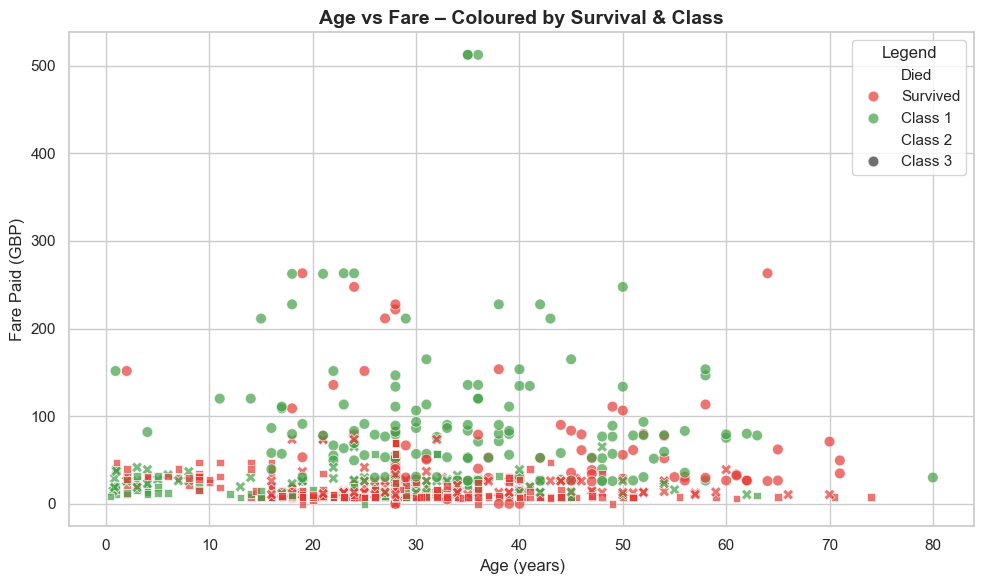

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
# Color dots by survival outcome
sns.scatterplot(data=df, x='Age', y='Fare',
hue='Survived', style='Pclass',
palette={0:'#E53935', 1:'#43A047'},
alpha=0.7, s=60, ax=ax)

ax.set_title('Age vs Fare – Coloured by Survival & Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Fare Paid (GBP)', fontsize=12)
# Update legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Died','Survived','Class 1','Class 2','Class 3'],

title='Legend', loc='upper right')

plt.tight_layout()
plt.savefig('chart6_age_vs_fare_scatter.png', dpi=150)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10192\4200821494.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='FamilySize', y='Survived', ax=axes[1,1],


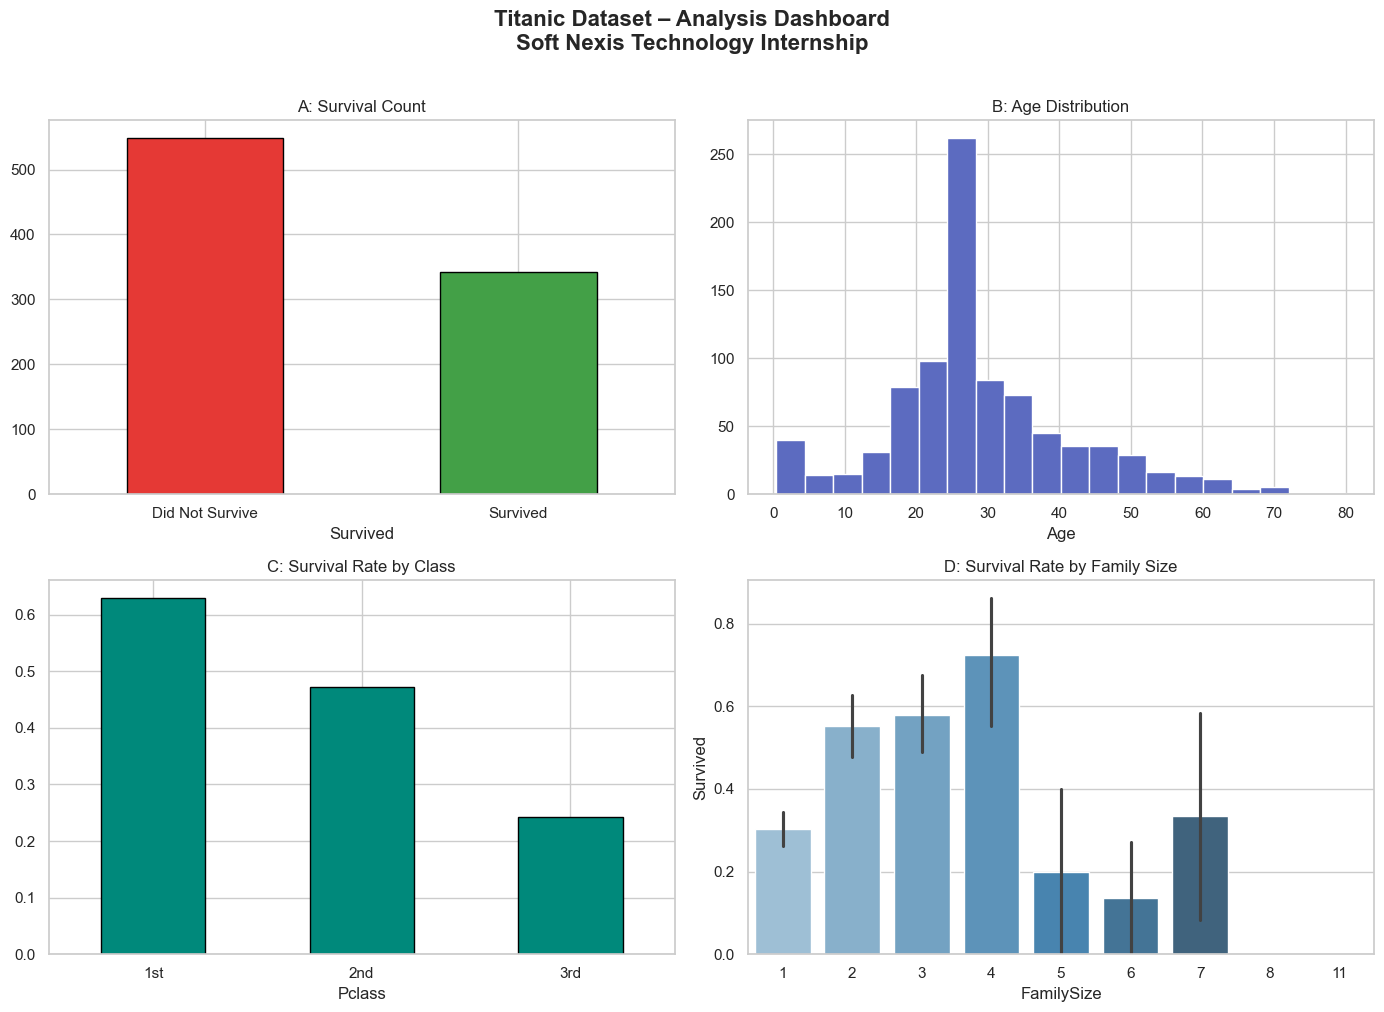

Dashboard saved!


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # 2 rows x 2 columns
fig.suptitle('Titanic Dataset – Analysis Dashboard\nSoft Nexis Technology Internship',

fontsize=16, fontweight='bold', y=1.01)

# Chart A: Survival count
df['Survived'].value_counts().plot(kind='bar', ax=axes[0,0],
color=['#E53935','#43A047'], edgecolor='black')
axes[0,0].set_title('A: Survival Count')
axes[0,0].set_xticklabels(['Did Not Survive','Survived'], rotation=0)
# Chart B: Age distribution
df['Age'].hist(bins=20, ax=axes[0,1], color='#5C6BC0', edgecolor='white')
axes[0,1].set_title('B: Age Distribution')
axes[0,1].set_xlabel('Age')
# Chart C: Survival by class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1,0],
color='#00897B', edgecolor='black')
axes[1,0].set_title('C: Survival Rate by Class')
axes[1,0].set_xticklabels(['1st','2nd','3rd'], rotation=0)
# Chart D: Family size vs survival
sns.barplot(data=df, x='FamilySize', y='Survived', ax=axes[1,1],

palette='Blues_d')

axes[1,1].set_title('D: Survival Rate by Family Size')
plt.tight_layout()
plt.savefig('dashboard_titanic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved!')